Load Taxi Zones Shape file

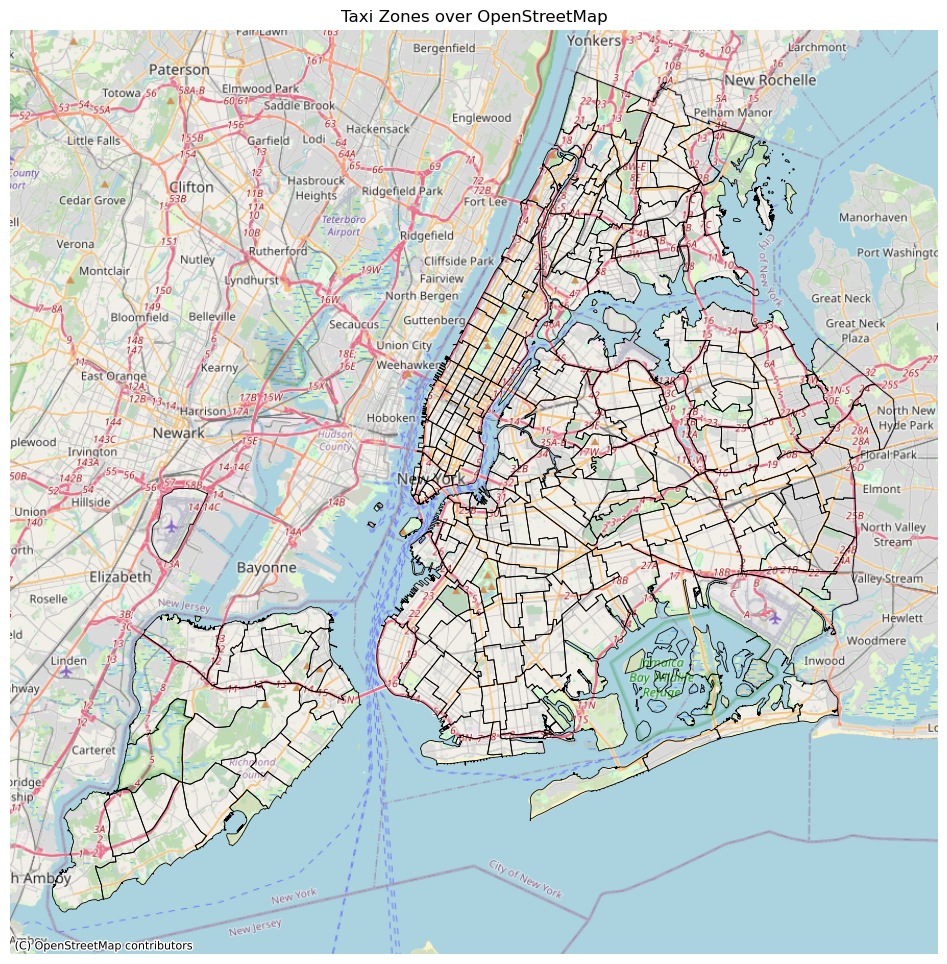

In [2]:
import geopandas as gpd
import contextily as ctx

import matplotlib.pyplot as plt

# read shapefile
shp_path = "taxi_zones/taxi_zones.shp"
gdf = gpd.read_file(shp_path)

# if CRS is missing, assume WGS84 (adjust if you know the correct CRS)
if gdf.crs is None:
    gdf = gdf.set_crs(epsg=4326)

# convert to Web Mercator for OSM basemap
gdf_web = gdf.to_crs(epsg=3857)

# plot
fig, ax = plt.subplots(figsize=(12, 12))
gdf_web.plot(ax=ax, edgecolor="black", facecolor="none", linewidth=0.6)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_axis_off()
ax.set_title("Taxi Zones over OpenStreetMap")
plt.show()

In [3]:
import pandas as pd
import os
import traceback
import numpy as np

ewr_id = 1
jfk_id = 132
lga_id = 138

# Define trip data types
trip_types = ['fhvhv', 'green', 'yellow']

# Dictionary to store aggregated results
airport_names = {ewr_id: 'EWR', jfk_id: 'JFK', lga_id: 'LGA'}

# FHVHV license to company mapping
fhvhv_companies = {
    'HV0002': 'Juno',
    'HV0003': 'Uber',
    'HV0004': 'Via',
    'HV0005': 'Lyft'
}

aggregated_data = []

# Loop through months 01-12 for 2023 trip data
for month in range(1, 13):
    month_str = f"{month:02d}"  # Format month as 01, 02, ..., 12
    
    for trip_type in trip_types:
        file_path = f"data/2023/{month_str}/{trip_type}_tripdata_2023-{month_str}.parquet"
        
        if os.path.exists(file_path):
            print(f"Processing: {file_path}")
            try:
                df = pd.read_parquet(file_path)
                print(f"  - Original shape: {df.shape}")
                
                pu_col = 'PULocationID' if 'PULocationID' in df.columns else 'PUlocationID'
                do_col = 'DOLocationID' if 'DOLocationID' in df.columns else 'DOlocationID'
                
                # Determine pickup and dropoff datetime columns
                # FHVHV: pickup_datetime, dropoff_datetime
                # GREEN: lpep_pickup_datetime, lpep_dropoff_datetime  
                # YELLOW: tpep_pickup_datetime, tpep_dropoff_datetime
                pickup_time_col = 'pickup_datetime' if 'pickup_datetime' in df.columns else 'tpep_pickup_datetime' if 'tpep_pickup_datetime' in df.columns else 'lpep_pickup_datetime'
                dropoff_time_col = 'dropoff_datetime' if 'dropoff_datetime' in df.columns else 'tpep_dropoff_datetime' if 'tpep_dropoff_datetime' in df.columns else 'lpep_dropoff_datetime'
                
                # Determine price columns (varies by trip type)
                # FHVHV: base_passenger_fare or total_amount
                # GREEN/YELLOW: total_amount
                if trip_type == 'fhvhv':
                    fhv_cols = ['base_passenger_fare', 'tolls', 'bcg', 'sales_tax', 'congestion_surcharge', 'airport_fee']
                    existing_cols = [c for c in fhv_cols if c in df.columns]
                    if existing_cols:
                        # sum available components, treating missing values as 0
                        df['price_sum'] = df[existing_cols].fillna(0).sum(axis=1)
                        price_col = 'price_sum'
                    else:
                        price_col = 'total_amount' if 'total_amount' in df.columns else None
                else:
                    price_col = 'total_amount' if 'total_amount' in df.columns else None
                
                print(f"  - Using columns: {pu_col}, {do_col}, {pickup_time_col}, {dropoff_time_col}, price={price_col}")
                
                # Filter for trips involving airports
                filtered_df = df[
                    (df[pu_col].isin([ewr_id, jfk_id, lga_id])) | 
                    (df[do_col].isin([ewr_id, jfk_id, lga_id]))
                ].copy()
                
                #print(f"  - Filtered shape: {filtered_df.shape}")
                
                # Process trips FROM airports
                from_airport = filtered_df[filtered_df[pu_col].isin([ewr_id, jfk_id, lga_id])].copy()
                if not from_airport.empty:
                    from_airport['airport'] = from_airport[pu_col].map(airport_names)
                    from_airport['direction'] = 'from'
                    from_airport['zone'] = from_airport[do_col]
                    from_airport['hour'] = pd.to_datetime(from_airport[pickup_time_col]).dt.hour
                    
                    # For FHVHV, map company name; for others use trip_type
                    if trip_type == 'fhvhv' and 'hvfhs_license_num' in from_airport.columns:
                        from_airport['trip_type'] = from_airport['hvfhs_license_num'].map(fhvhv_companies).fillna('Other_FHVHV')
                    else:
                        from_airport['trip_type'] = trip_type
                    
                    # Calculate travel time in minutes
                    from_airport['travel_time_min'] = (
                        pd.to_datetime(from_airport[dropoff_time_col]) - 
                        pd.to_datetime(from_airport[pickup_time_col])
                    ).dt.total_seconds() / 60
                    
                    # Get price column if available
                    from_airport['price'] = from_airport[price_col]
                    
                    # Keep only rows with valid travel time (positive and reasonable)
                    #from_airport = from_airport[
                    #    (from_airport['travel_time_min'] > 0) & 
                    #    (from_airport['travel_time_min'] < 300)  # Less than 5 hours
                    #]
                    
                    aggregated_data.append(from_airport[['airport', 'direction', 'zone', 'hour', 'trip_type', 'travel_time_min', 'price']])
                
                # Process trips TO airports
                to_airport = filtered_df[filtered_df[do_col].isin([ewr_id, jfk_id, lga_id])].copy()
                if not to_airport.empty:
                    to_airport['airport'] = to_airport[do_col].map(airport_names)
                    to_airport['direction'] = 'to'
                    to_airport['zone'] = to_airport[pu_col]
                    to_airport['hour'] = pd.to_datetime(to_airport[dropoff_time_col]).dt.hour
                    
                    # For FHVHV, map company name; for others use trip_type
                    if trip_type == 'fhvhv' and 'hvfhs_license_num' in to_airport.columns:
                        to_airport['trip_type'] = to_airport['hvfhs_license_num'].map(fhvhv_companies).fillna('Other_FHVHV')
                    else:
                        to_airport['trip_type'] = trip_type
                    
                    # Calculate travel time in minutes
                    to_airport['travel_time_min'] = (
                        pd.to_datetime(to_airport[dropoff_time_col]) - 
                        pd.to_datetime(to_airport[pickup_time_col])
                    ).dt.total_seconds() / 60
                    
                    # Get price column if available
                    if price_col and price_col in to_airport.columns:
                        to_airport['price'] = to_airport[price_col]
                    else:
                        to_airport['price'] = np.nan
                    
                    # Keep only rows with valid travel time (positive and reasonable)
                    to_airport = to_airport[
                        (to_airport['travel_time_min'] > 0) & 
                        (to_airport['travel_time_min'] < 300)  # Less than 5 hours
                    ]
                    
                    aggregated_data.append(to_airport[['airport', 'direction', 'zone', 'hour', 'trip_type', 'travel_time_min', 'price']])
                
            except KeyError as e:
                print(f"  - KeyError: {e}")
                print(f"  - Available columns: {df.columns.tolist()}")
                traceback.print_exc()
            except Exception as e:
                print(f"  - Error: {e}")
                traceback.print_exc()
            
        else:
            print(f"File not found: {file_path}")


Processing: data/2023/01/fhvhv_tripdata_2023-01.parquet
  - Original shape: (18479031, 24)
  - Original shape: (18479031, 24)
  - Using columns: PULocationID, DOLocationID, pickup_datetime, dropoff_datetime, price=price_sum
  - Using columns: PULocationID, DOLocationID, pickup_datetime, dropoff_datetime, price=price_sum
Processing: data/2023/01/green_tripdata_2023-01.parquet
Processing: data/2023/01/green_tripdata_2023-01.parquet
  - Original shape: (68211, 20)
  - Using columns: PULocationID, DOLocationID, lpep_pickup_datetime, lpep_dropoff_datetime, price=total_amount
Processing: data/2023/01/yellow_tripdata_2023-01.parquet
  - Original shape: (68211, 20)
  - Using columns: PULocationID, DOLocationID, lpep_pickup_datetime, lpep_dropoff_datetime, price=total_amount
Processing: data/2023/01/yellow_tripdata_2023-01.parquet
  - Original shape: (3066766, 19)
  - Using columns: PULocationID, DOLocationID, tpep_pickup_datetime, tpep_dropoff_datetime, price=total_amount
  - Original shape: (

In [ ]:
# Combine all aggregated data
if aggregated_data:
    print("\n" + "="*80)
    print("COMBINING AND AGGREGATING DATA...")
    print("="*80)
    
    all_trips_df = pd.concat(aggregated_data, ignore_index=True)
    print(f"Total trips collected: {len(all_trips_df)}")
    
    # First, aggregate by date to get daily statistics for each hour
    # Extract date from the data by grouping
    print("\nCalculating daily statistics by hour...")
    
    # Aggregate by airport, direction, zone, hour, trip_type
    # This gives us statistics across all days of the year
    final_df = all_trips_df.groupby(['airport', 'direction', 'zone', 'hour', 'trip_type']).agg(
        count=('travel_time_min', 'count'),
        travel_time_mean=('travel_time_min', 'mean'),
        travel_time_var=('travel_time_min', 'var'),
        travel_time_std=('travel_time_min', 'std'),
        price_mean=('price', 'mean'),
        price_var=('price', 'var'),
        price_std=('price', 'std')
    ).reset_index()
    
    # Sort by airport, direction, zone, and hour
    final_df = final_df.sort_values(['airport', 'direction', 'zone', 'hour', 'trip_type'])
    
    print("\n" + "="*80)
    print("AGGREGATED RESULTS BY HOUR (across all days):")
    print("="*80)
    print(final_df.head(30))
    print(f"\nTotal rows: {len(final_df)}")
    print(f"\nSummary by airport and direction:")
    summary = final_df.groupby(['airport', 'direction']).agg({
        'count': 'sum',
        'travel_time_mean': 'mean',
        'price_mean': 'mean'
    })
    print(summary)
    
    # Save detailed results to CSV
    output_file = 'tncdata_processed/airport_trips_aggregated_2023.csv'
    final_df.to_csv(output_file, index=False)
    print(f"\n✓ Saved detailed results to: {output_file}")
    
    # Create hourly summary by zone (not aggregating across zones)
    print("\n" + "="*80)
    print("HOURLY SUMMARY BY ZONE (mean, variance, and std dev for each zone-hour):")
    print("="*80)
    
    # Aggregate across trip types only, keeping zones separate
    hourly_summary = final_df.groupby(['airport', 'direction', 'zone', 'hour']).agg(
        total_trips=('count', 'sum'),
        avg_travel_time=('travel_time_mean', 'mean'),
        var_travel_time=('travel_time_mean', 'var'),
        std_travel_time=('travel_time_mean', 'std'),
        avg_price=('price_mean', 'mean'),
        var_price=('price_mean', 'var'),
        std_price=('price_mean', 'std')
    ).reset_index()
    
    hourly_summary = hourly_summary.sort_values(['airport', 'direction', 'zone', 'hour'])
    print(hourly_summary.head(50))
    print(f"\nTotal rows: {len(hourly_summary)}")
    
    # Save hourly summary by zone
    hourly_output_file = 'tncdata_processed/airport_trips_hourly_by_zone_2023.csv'
    hourly_summary.to_csv(hourly_output_file, index=False)
    print(f"\n✓ Saved hourly summary by zone to: {hourly_output_file}")
    
else:
    print("No data to aggregate")
    final_df = None
    hourly_summary = None


COMBINING AND AGGREGATING DATA...
Total trips collected: 25020058

Calculating daily statistics by hour...

AGGREGATED RESULTS BY HOUR (across all days):
   airport direction  zone  hour trip_type  count  travel_time_mean  \
0      EWR      from     1     0    yellow     15          0.382222   
1      EWR      from     1     1    yellow     32          0.321875   
2      EWR      from     1     2    yellow     32          0.740625   
3      EWR      from     1     3      Uber      1          3.916667   
4      EWR      from     1     3    yellow     49          0.377211   
5      EWR      from     1     4      Uber      3          3.827778   
6      EWR      from     1     4     green      1          1.416667   
7      EWR      from     1     4    yellow     98          0.329762   
8      EWR      from     1     5      Uber      2          4.158333   
9      EWR      from     1     5     green      1          0.083333   
10     EWR      from     1     5    yellow    138          0.717

OSError: Cannot save file into a non-existent directory: 'tnc_data_output'